In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import sys
sys.path.append('/home/kutulu/projects/code-of-kutulu-client')

In [3]:
import torch

In [4]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime
import pickle as pkl
import zlib
import base64
import torch

In [5]:

from src.envs.trainer import Trainer
from src.envs.strategy import LazyGreedyStrategy, LazyGreedyStrategy2, RandomStrategy
from src.game.template import DEFAULT_KUTULU_ACTIONS, EXTENDED_KUTULU_ACTIONS
from src.envs.kutulu_observer import viz_observation
from src.envs.agents.reinforce_agent import REINFORCEAgent

In [6]:
agents_info = [
    {
        'train': True,
        'type': 'qdn_conv',
        'action_space_n': 8,
        'state_type': 'conv',
        'gamma': 0.1,
        'replay_start_size': 1000,
        'batch_size': 32,
        'sync_target_frames': 1000,
        'epsilon_decay_last_frame': int(1 * 10**5),
        'gamma': 0.5,
        'size': 3,
        'replay_start_size': 10000,
        'batch_size': 32,
        'sync_target_frames': 1000,
        'lr': 1e-5,
        'replay_size': 10000,
        'epsilon_decay_last_frame': int(2 * 10**5),
        'loss': 'huber',
    },
    # {
    #     'train': True,
    #     'type': 'reinforce',
    #     'action_space_n': 8,
    #     'state_type': 'closest_ext',
    #     'gamma': 0.3,
    #     'epsilon_decay_last_frame': int(2 * 10**5)
    # },
    {
        'train': False,
        'type': 'qlearning',
        'action_space_n': 8,
        'state_type': 'closest',
        'strategy': 'random',
    },
    {
        'train': False,
        'type': 'qlearning',
        'action_space_n': 8,
        'state_type': 'closest',
        'strategy': 'random',
    },
    {
        'train': False,
        'type': 'qlearning',
        'action_space_n': 8,
        'state_type': 'closest',
        'strategy': 'random',
    },
]

In [7]:
trainer = Trainer(
    num_experiments=1, agents_info=agents_info, shuffle=False,
    league_level=3, actions=EXTENDED_KUTULU_ACTIONS, log_dir='../runs'
)

In [8]:
trainer

In [9]:
self = trainer

In [10]:
seed = 1
verbose = False

In [11]:

env = self.reset_env(seed)

In [12]:
state = trainer.agents[0].observer.get_state(0)

In [50]:
clockwise_dir = 3

In [51]:
def state_rotation_augment(state, clockwise_dir):
    return {k: np.rot90(v, k=-clockwise_dir) for k, v in state.items()}

In [65]:
def action_rotation_augment(action, clockwise_dir):
    clockwise_dir = clockwise_dir % 4
    assert clockwise_dir >= 0 and clockwise_dir < 4
    if action >= 4:
        return action
    return (action + clockwise_dir) % 4

In [66]:
for i in range(5):
    print(i, action_rotation_augment(3, i))

0 3
1 0
2 1
3 2
4 3


In [14]:
states = trainer.agents[0].episode_buffer.encode_states([state])

In [15]:
states.shape

torch.Size([1, 12, 7, 7])

In [16]:
states

tensor([[[[  0.,   1.,   0.,   1.,   0.,   0.,   1.],
          [  0.,   1.,   1.,   1.,   0.,   0.,   1.],
          [  1.,   2.,   0.,   1.,   1.,   1.,   1.],
          [  1.,   0.,   0.,   1.,   0.,   0.,   1.],
          [  1.,   0.,   0.,   1.,   0.,   0.,   1.],
          [  1.,   2.,   0.,   1.,   1.,   1.,   1.],
          [  0.,   1.,   1.,   1.,   0.,   0.,   1.]],

         [[  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0., 250.,   0.,   0., 250.],
          [  0.,   0.,   0., 250.,   0.,   0., 250.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.]],

         [[  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   2.,   0.,   0.,   2.],
          [  0.,   0.,  

In [17]:
self = trainer.agents[0].model

In [18]:
self(states)

tensor([[ 1.3598, -0.1563,  0.2600,  0.1020, -3.2224, -2.2571,  0.9676,  1.7091]],
       grad_fn=<AddmmBackward0>)

In [21]:
trainer.agents[0].size

3

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [25]:
size = 3

In [49]:
conv1 = nn.Conv2d(12, 16, kernel_size=5, padding=1)
conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
pool = nn.MaxPool2d(2, 2)  # уменьшает размер в 2 раза
fc1 = nn.Linear(32 * (size - 1) * (size - 1), 64)  # предполагаем вход размером 10x10
fc2 = nn.Linear(64, 5)

In [51]:
x = states
x = F.relu(conv1(x))  # [B, 16, H, W]
x = pool(F.relu(conv2(x)))  # [B, 32, H/2, W/2]
x = torch.flatten(x, 1)  # [B, 32*H/2*W/2]
x = F.relu(fc1(x))
x = fc2(x)

In [37]:
x.shape

torch.Size([1, 32, 3, 3])

In [15]:

import torch.nn.functional as F

In [18]:
x = states
x = F.relu(self.conv1(x))  # [B, 16, H, W]
x = self.pool(F.relu(self.conv2(x)))  # [B, 32, H/2, W/2]
x = torch.flatten(x, 1)  # [B, 32*H/2*W/2]
x = F.relu(self.fc1(x))
x = self.fc2(x)

In [19]:
self(states)

tensor([[ 0.6895, -1.0983,  0.5671,  0.7297,  0.2932, -0.9210,  0.2693, -0.0953]],
       grad_fn=<AddmmBackward0>)

In [31]:
32 * 3 * 3

288

In [10]:
self = trainer.agents[0].observer

In [59]:
from src.envs.kutulu_observer import BaseKutuluClosestObserver
from src.envs.kutulu_world import KutuluWorldEnv

In [62]:

MAP_MAP = {
    '#': 0,
    '.': 1,
    'w': 1,
    's': 1,
    'S': 1,
    'U': 2,
}
FEATURE_ENTITY_DICT = {
    'EXPLORER': ['param0', 'param1', 'param2'],
    'WANDERER': ['param0', 'param1'],
    'SLASHER': ['param0', 'param1'],
    'EFFECT_PLAN': ['param0'],
    'EFFECT_LIGHT': ['param0'],
    'EFFECT_SHELTER': ['param0'],
    'EFFECT_YELL': ['param0']
}

In [66]:
def get_state_conv(player_id, entities, lines, size):
    data = {}
    curr_map = [list(line) for line in lines]
    agent_entity = None
    for e in entities:
        if e['id'] == player_id:
            agent_pos = (e['x'], e['y'])
            agent_entity = e
    assert agent_entity is not None
    curr_map = [[MAP_MAP['#']] * int(size * 2 + 1) for i in range(int(size * 2 + 1))]
    for rel_x in range(-size, size + 1):
        for rel_y in range(-size, size + 1):
            y = agent_pos[1] + rel_y
            x = agent_pos[0] + rel_x
            if 0 <= y and y < len(lines) and 0 <= x and x < len(lines[0]):
                curr_map[size + rel_y][size + rel_x] = MAP_MAP[lines[y][x]]
    data['map'] = curr_map
    for kind, features in FEATURE_ENTITY_DICT.items():
        for feature in features:
            curr_map = [[0] * int(size * 2 + 1) for i in range(int(size * 2 + 1))]
            if kind == 'EXPLORER':
                curr_map[size][size] = agent_entity[feature]
            for e in entities:
                if kind == 'EXPLORER' and e['id'] == agent_entity['id']:
                    continue
                rel_x = max(min(e['x'] - agent_pos[0], size), -size)
                rel_y = max(min(e['y'] - agent_pos[1], size), -size)
                if abs(rel_x) <= size and abs(rel_y) <= size and e['kind'] == kind:
                    curr_map[size + rel_y][size + rel_x] = e[feature]
            data[f'{kind}_{feature}'] = curr_map
    return data

In [67]:
class KutuluConvObserver(BaseKutuluClosestObserver):
    def __init__(self, env: KutuluWorldEnv, size: int):
        super(KutuluConvObserver, self).__init__(env)
        self.size = size

    def get_state(self, player_id):
        _obs = self.env._get_obs(player_id)
        entities = _obs['entities']
        info = self.env._get_info()
        
        state = get_state_conv(player_id, entities, self.env.map, self.size)
        return state

In [68]:
KutuluConvObserver(self.env, size=2).get_state(player_id=0)

{'map': [[1, 1, 1, 0, 0],
  [2, 0, 1, 1, 1],
  [0, 0, 1, 0, 0],
  [0, 0, 1, 0, 0],
  [2, 0, 1, 1, 1]],
 'EXPLORER_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 250, 0, 250],
  [0, 0, 250, 0, 250],
  [0, 0, 0, 0, 0]],
 'EXPLORER_param1': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 2, 0, 2],
  [0, 0, 2, 0, 2],
  [0, 0, 0, 0, 0]],
 'EXPLORER_param2': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 3, 0, 3],
  [0, 0, 3, 0, 3],
  [0, 0, 0, 0, 0]],
 'WANDERER_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'WANDERER_param1': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'SLASHER_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'SLASHER_param1': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'EFFECT_PLAN_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0

In [48]:
size = 2
data = {}

In [49]:
player_id = 0

In [50]:
entities = self.env._get_obs(player_id)['entities']

In [51]:
info = self.env._get_info()

In [52]:
lines = info['lines']
curr_map = [list(line) for line in lines]
agent_entity = None
for e in entities:
    if e['id'] == player_id:
        agent_pos = (e['x'], e['y'])
        agent_entity = e

In [53]:
curr_map = [[MAP_MAP['#']] * int(size * 2 + 1) for i in range(int(size * 2 + 1))]
for rel_x in range(-size, size + 1):
    for rel_y in range(-size, size + 1):
        y = agent_pos[1] + rel_y
        x = agent_pos[0] + rel_x
        if 0 <= y and y < len(lines) and 0 <= x and x < len(lines[0]):
            curr_map[size + rel_y][size + rel_x] = MAP_MAP[lines[y][x]]
data['map'] = curr_map
for kind, features in FEATURE_ENTITY_DICT.items():
    for feature in features:
        curr_map = [[0] * int(size * 2 + 1) for i in range(int(size * 2 + 1))]
        if kind == 'EXPLORER':
            curr_map[size][size] = agent_entity[feature]
        for e in entities:
            if kind == 'EXPLORER' and e['id'] == agent_entity['id']:
                continue
            rel_x = max(min(e['x'] - agent_pos[0], size), -size)
            rel_y = max(min(e['y'] - agent_pos[1], size), -size)
            if abs(rel_x) <= size and abs(rel_y) <= size and e['kind'] == kind:
                curr_map[size + rel_y][size + rel_x] = e[feature]
        data[f'{kind}_{feature}'] = curr_map

In [54]:
data

{'map': [[1, 1, 1, 0, 0],
  [2, 0, 1, 1, 1],
  [0, 0, 1, 0, 0],
  [0, 0, 1, 0, 0],
  [2, 0, 1, 1, 1]],
 'EXPLORER_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 250, 0, 250],
  [0, 0, 250, 0, 250],
  [0, 0, 0, 0, 0]],
 'EXPLORER_param1': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 2, 0, 2],
  [0, 0, 2, 0, 2],
  [0, 0, 0, 0, 0]],
 'EXPLORER_param2': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 3, 0, 3],
  [0, 0, 3, 0, 3],
  [0, 0, 0, 0, 0]],
 'WANDERER_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'WANDERER_param1': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'SLASHER_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'SLASHER_param1': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0]],
 'EFFECT_PLAN_param0': [[0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0],
  [0, 0

In [17]:
rollout_rewards = trainer.play_rollout(14)

In [18]:
buffer = trainer.agents[0].episode_buffer.buffer

In [19]:
len(buffer)

127

In [37]:
episode = buffer[0]

In [38]:
EXTENDED_KUTULU_ACTIONS[episode.action]

'PLAN'

In [41]:
viz_observation(episode.observation, episode.action)

###############
#.............#
#.#.#.#.#.#.#.#
#..w.......w..#
#.#.#.#.#.#.#.#
#....A...1....#
#.#.#.#.#.#.#.#
#....2...3....#
#.#.#.#.#.#.#.#
#..w.......w..#
#.#.#.#.#.#.#.#
#.............#
###############



In [47]:
from src.envs.kutulu_observer import VIZ_MAP

In [51]:
def print_exp(state):
    lines = [['.'] * 7 for i in range(7)]
    lines[3][3] = '0'
    for e in state:
        if abs(e['rel_x']) <= 3 and abs(e['rel_y']) <= 3:
            lines[3 + e['rel_y']][3 + e['rel_x']] = VIZ_MAP[e['kind']]
            print(e)
    for l in lines:
        print(''.join(l))

In [52]:
print_exp(episode.state)

{'kind': 'EXPLORER', 'param0': 250, 'param1': 2, 'param2': 3, 'rel_x': 0, 'rel_y': 2, 'dist': 2, 'dir': (2,), 'raw_dist': 2, 'on_los': True}
.......
.......
.......
...0...
.......
...E...
.......


In [53]:
print_exp(episode.new_state)

{'kind': 'EXPLORER', 'param0': 249, 'param1': 2, 'param2': 2, 'rel_x': 0, 'rel_y': 2, 'dist': 2, 'dir': (2,), 'raw_dist': 2, 'on_los': True}
{'kind': 'EFFECT_PLAN', 'param0': 4, 'param1': 0, 'param2': -1, 'rel_x': 0, 'rel_y': 0, 'dist': 0, 'dir': (4,), 'raw_dist': 0, 'on_los': True}
{'kind': 'EFFECT_LIGHT', 'param0': 2, 'param1': 2, 'param2': -1, 'rel_x': 0, 'rel_y': 2, 'dist': 2, 'dir': (2,), 'raw_dist': 2, 'on_los': True}
.......
.......
.......
...P...
.......
...L...
.......


In [25]:
episode.reward

0.2

In [26]:
episode.state

[{'kind': 'EXPLORER',
  'param0': 250,
  'param1': 2,
  'param2': 3,
  'rel_x': 4,
  'rel_y': 0,
  'dist': 4,
  'dir': (1,),
  'raw_dist': 4,
  'on_los': True},
 {'kind': 'EXPLORER',
  'param0': 250,
  'param1': 2,
  'param2': 3,
  'rel_x': 0,
  'rel_y': 2,
  'dist': 2,
  'dir': (2,),
  'raw_dist': 2,
  'on_los': True},
 {'kind': 'EXPLORER',
  'param0': 250,
  'param1': 2,
  'param2': 3,
  'rel_x': 4,
  'rel_y': 2,
  'dist': 6,
  'dir': (1, 2),
  'raw_dist': 6,
  'on_los': False}]

In [27]:
episode.new_state

[{'kind': 'EXPLORER',
  'param0': 247,
  'param1': 2,
  'param2': 2,
  'rel_x': 4,
  'rel_y': 0,
  'dist': 4,
  'dir': (1,),
  'raw_dist': 4,
  'on_los': True},
 {'kind': 'EXPLORER',
  'param0': 249,
  'param1': 2,
  'param2': 2,
  'rel_x': 0,
  'rel_y': 2,
  'dist': 2,
  'dir': (2,),
  'raw_dist': 2,
  'on_los': True},
 {'kind': 'EXPLORER',
  'param0': 247,
  'param1': 2,
  'param2': 3,
  'rel_x': 5,
  'rel_y': 2,
  'dist': 7,
  'dir': (1, 2),
  'raw_dist': 7,
  'on_los': False},
 {'kind': 'EFFECT_PLAN',
  'param0': 4,
  'param1': 0,
  'param2': -1,
  'rel_x': 0,
  'rel_y': 0,
  'dist': 0,
  'dir': (4,),
  'raw_dist': 0,
  'on_los': True},
 {'kind': 'EFFECT_LIGHT',
  'param0': 2,
  'param1': 1,
  'param2': -1,
  'rel_x': 4,
  'rel_y': 0,
  'dist': 4,
  'dir': (1,),
  'raw_dist': 4,
  'on_los': True},
 {'kind': 'EFFECT_LIGHT',
  'param0': 2,
  'param1': 2,
  'param2': -1,
  'rel_x': 0,
  'rel_y': 2,
  'dist': 2,
  'dir': (2,),
  'raw_dist': 2,
  'on_los': True}]

In [ ]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])
winner_list = np.argmax(total_reward_list, 1)
Counter(winner_list)

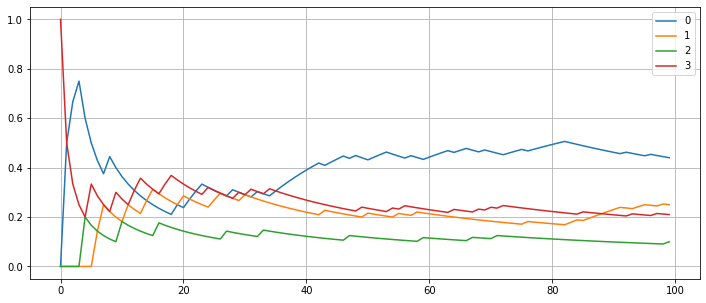

In [8]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [9]:
model_dir_list

[]

In [ ]:
# '../output/2025-05-22/21:52:42.972193'

In [7]:
val_trainer = Trainer(
    num_experiments=100, agents_info=agents_info,
    league_level=3, 
    actions=EXTENDED_KUTULU_ACTIONS,
)

In [14]:
# checkpoints_dir = '../output/2025-05-22/21:52:42.972193'

In [15]:
for i,agent in enumerate(trainer.agents):
    checkpoint_dir = f'{checkpoints_dir}/agent{i}'
    agent.load_agent(checkpoint_dir)
    agent.train = False
    break

In [16]:
reward_list = []
quality_list = []

for i in tqdm(range(val_trainer.num_experiments)):
    rollout_rewards = val_trainer.play_rollout()
    reward_list.append(rollout_rewards)
    quality_list.append(val_trainer.agents[0].check_policy())

  2%|▏         | 2/100 [00:01<00:49,  1.96it/s]/Users/aleksei/projects/code-of-kutulu-client/src/envs/agents/dqn_agent.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  states = self.encode_states(np.array(states))
/Users/aleksei/projects/code-of-kutulu-client/src/envs/agents/dqn_agent.py:66: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  next_states = self.encode_states(np.array(next_states))
100%|██████████| 100/100 [01:52<00:00,  1.12s/it]


In [32]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])
winner_list = np.argmax(total_reward_list, 1)
Counter(winner_list)

Counter({0: 35, 1: 29, 3: 20, 2: 16})

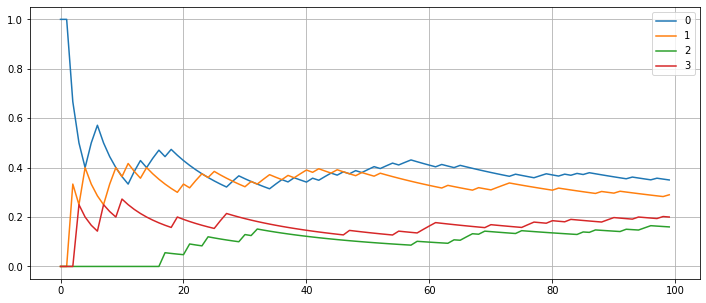

In [34]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()